# Schema design

This tutorial covers how to design DataJoint schemas effectively. You'll learn:

* Table tiers — Manual, Lookup, Imported, and Computed tables
* Primary keys — Uniquely identifying entities
* Foreign keys — Creating dependencies between tables
* Relationship patterns — One-to-many, one-to-one, and many-to-many

We'll build a schema for a neuroscience experiment tracking subjects, sessions, and trials.

In [1]:
import datajoint as dj

In [2]:
# confirm connection and 
print("Host:", dj.config.get("database.host"))
print("User:", dj.config.get("database.user"))

# open a connection to MySQL through DataJoint
conn = dj.conn()
print("Connected:", conn.is_connected)

# create new schema in MySQL

schema = dj.Schema('tutorial_design')
print("Schema ready:", schema.database)

Host: 127.0.0.1
User: djuser
[2026-04-01 18:43:59] DataJoint 2.1.1 connected to djuser@127.0.0.1:3306
Connected: True
Schema ready: tutorial_design


## Table Tiers

DataJoint has four table tiers, each serving a different purpose:

| Tier     | Class         | Purpose                          | Data Entry                                   |
|----------|--------------|----------------------------------|----------------------------------------------|
| Manual   | dj.Manual    | Core experimental data           | Inserted by operators or instruments         |
| Lookup   | dj.Lookup    | Reference/configuration data     | Pre-populated, rarely changes                |
| Imported | dj.Imported  | Data from external files         | Auto-populated via `make()`                  |
| Computed | dj.Computed  | Derived/processed data           | Auto-populated via `make()`                  |

Manual tables are not necessarily populated by hand—they contain data entered into the pipeline by operators, instruments, or ingestion scripts using insert commands. In contrast, Imported and Computed tables are auto-populated by calling the `.populate()` method, which invokes the `make()` callback for each missing entry.

## Manual tables

In [3]:
@schema
class Lab(dj.Manual):
    definition = """
    # Research laboratory
    lab_id : varchar(16)            # short identifier (e.g., 'tolias')
    ---
    lab_name : varchar(100)
    institution : varchar(100)
    created_at = CURRENT_TIMESTAMP : datetime   # when record was created
    """

@schema
class Subject(dj.Manual):
    definition = """
    # Experimental subject
    subject_id : varchar(16)
    ---
    -> Lab
    species : varchar(50)
    date_of_birth : date
    sex : enum('M', 'F', 'U')
    """

## Lookup Tables


Lookup tables store reference data that rarely changes. Use the contents attribute to pre-populate them.

In [5]:
@schema
class TaskType(dj.Lookup):
    definition = """
    # Types of behavioral tasks
    task_type : varchar(32)
    ---
    description : varchar(255)
    """
    contents = [
        {'task_type': 'go_nogo', 'description': 'Go/No-Go discrimination task'},
        {'task_type': '2afc', 'description': 'Two-alternative forced choice'},
        {'task_type': 'foraging', 'description': 'Foraging/exploration task'},
    ]

@schema
class SessionStatus(dj.Lookup):
    definition = """
    # Session status codes
    status : varchar(16)
    """
    contents = [
        {'status': 'scheduled'},
        {'status': 'in_progress'},
        {'status': 'completed'},
        {'status': 'aborted'},
    ]

In [8]:
# Lookup tables are automatically populated
TaskType()

task_type,description
2afc,Two-alternative forced choice
foraging,Foraging/exploration task
go_nogo,Go/No-Go discrimination task


## Primary Keys


- The **primary key** uniquely identifies each row  
- Attributes above the `---` line form the primary key  

#### Design Principles
- **Entity integrity** — each row represents one real-world entity  
- **No duplicates** — prevents inserting the same entity twice  
- **Minimal** — include only attributes needed for uniqueness  

#### Natural vs Surrogate Keys

- **Natural key**  
  - Real-world identifier (used outside the database)  
  - Requires a physical or external labeling system (e.g., tags, barcodes)  
  - Example: `subject_id = 'M001'`  

- **Surrogate key**  
  - Internal database identifier (not used by end users)  
  - Typically auto-generated (e.g., IDs, UUIDs)  

**In DataJoint:**  
- Natural keys improve interpretability and link to real entities  
- Surrogate keys are useful for internal-only entities or privacy-sensitive data 

In [ ]:
@schema
class Session(dj.Manual):
    definition = """
    # Experimental session
    -> Subject
    session_idx : int32            # session number for this subject
    ---
    -> TaskType
    -> SessionStatus
    session_date : date
    session_notes = '' : varchar(1000)
    task_params = NULL : json       # task-specific parameters (nullable)
    """

    class Trial(dj.Part):
        definition = """
        # Individual trial within a session
        -> master                  # use the primary key of the enclosing master table here
        trial_idx : int32
        ---
        stimulus : varchar(50)
        response : varchar(50)
        correct : bool
        reaction_time : decimal(3,2)  # seconds
        """

## Foreign Keys

The `->` syntax creates a foreign key dependency. Foreign keys:

- **Import attributes** — primary key attributes are inherited from the parent  
- **Enforce referential integrity** — prevents inserting related data without an existing parent  
- **Enable cascading deletes** — deleting a parent removes dependent records  
- **Define workflow** — the parent must exist before the child  

In [10]:
# Let's insert some data to see how foreign keys work
Lab.insert1({
    'lab_id': 'tolias',
    'lab_name': 'Tolias Lab',
    'institution': 'Baylor College of Medicine'
})
# Note: created_at is auto-populated with CURRENT_TIMESTAMP

Subject.insert1({
    'subject_id': 'M001',
    'lab_id': 'tolias',
    'species': 'Mus musculus',
    'date_of_birth': '2026-01-15',
    'sex': 'M'
})

Subject()

subject_id,lab_id,species,date_of_birth,sex
M001,tolias,Mus musculus,2026-01-15,M


In [11]:
# Insert sessions for this subject
Session.insert([
    {'subject_id': 'M001', 'session_idx': 1, 'task_type': 'go_nogo', 
     'status': 'completed', 'session_date': '2026-01-06',
     'task_params': {'go_probability': 0.5, 'timeout_sec': 2.0}},
    {'subject_id': 'M001', 'session_idx': 2, 'task_type': 'go_nogo',
     'status': 'completed', 'session_date': '2026-01-07',
     'task_params': {'go_probability': 0.7, 'timeout_sec': 1.5}},
    {'subject_id': 'M001', 'session_idx': 3, 'task_type': '2afc',
     'status': 'in_progress', 'session_date': '2026-01-08',
     'task_params': None},  # NULL - no parameters for this session
])

Session()

subject_id,session_idx,task_type,status,session_date,session_notes,task_params
M001,1,go_nogo,completed,2026-01-06,,json
M001,2,go_nogo,completed,2026-01-07,,json
M001,3,2afc,in_progress,2026-01-08,,json


In [12]:
# This would fail - referential integrity prevents invalid foreign keys
try:
    Session.insert1({'subject_id': 'INVALID', 'session_idx': 1, 
                     'task_type': 'go_nogo', 'status': 'completed',
                     'session_date': '2026-01-06'})
except Exception as e:
    print(f"Error: {type(e).__name__}")
    print("Cannot insert session for non-existent subject!")

Error: IntegrityError
Cannot insert session for non-existent subject!


## Relationship Patterns

#### One-to-Many (Hierarchical)
- When a foreign key is part of the primary key, it creates a one-to-many relationship  
- Examples:  
  - One subject → many sessions  
  - One session → many trials  

#### Master-Part (Compositional Integrity)
- Ensures master and dependent data are inserted and deleted together  
- Part tables:  
  - Reference the master using `-> master`  
  - Are inserted atomically with the master  
  - Are deleted when the master is deleted  
  - Can be one-to-many or one-to-one  
- A master can have multiple interconnected part tables  

**Example:** `Session.Trial`  
- Trials belong to a session and are managed together  
- Deleting a session removes all trials  
- Ensures complete data before downstream processing  

**Use case:**  
- Apply part tables when all components must be present before processing begins  

In [13]:
# Access the part table
Session.Trial()

subject_id,session_idx,trial_idx,stimulus,response,correct,reaction_time


#### One-to-One (Extension)

- Occurs when the child’s primary key exactly matches the parent’s  
- Creates a one-to-one relationship  

**Uses**  
- Extend a table with optional or computed data  
- Separate computed results from source data  

**Example:**  
- `SessionSummary` ↔ `Session`  
  - Each session has exactly one summary  

In [14]:
@schema
class SessionSummary(dj.Computed):
    definition = """
    # Summary statistics for a session
    -> Session
    ---
    num_trials : int32
    num_correct : int32
    accuracy : float32
    mean_reaction_time : float32
    """
    
    def make(self, key):
        correct_vals, rt_vals = (Session.Trial & key).to_arrays('correct', 'reaction_time')
        rt_vals = rt_vals.astype(float)  # convert decimal to float
        n_trials = len(correct_vals)
        n_correct = sum(correct_vals) if n_trials else 0

        self.insert1({
            **key,
            'num_trials': n_trials,
            'num_correct': n_correct,
            'accuracy': n_correct / n_trials if n_trials else 0.0,
            'mean_reaction_time': sum(rt_vals) / n_trials if n_trials else 0.0
        })

## Foreign Key Modifiers

Foreign keys support modifiers that change their behavior:

| Modifier  | Syntax                          | Effect                                      |
|-----------|----------------------------------|---------------------------------------------|
| Nullable  | `-> [nullable] Table`           | Makes the foreign key optional (can be NULL)|
| Unique    | `-> [unique] Table`             | Enforces one-to-one from the child side     |
| Both      | `-> [nullable, unique] Table`   | Optional one-to-one relationship            |

#### Rules
- `[nullable]` is only allowed for secondary foreign keys (below `---`)  
- `[unique]` is allowed for both primary and secondary foreign keys  
- Primary key attributes cannot be nullable  

#### Note
- With `nullable + unique`, multiple rows can have `NULL` values  
- This is because SQL `UNIQUE` constraints treat `NULL` values as distinct  

In [15]:
@schema
class Experimenter(dj.Manual):
    definition = """
    # Lab member who runs experiments
    experimenter_id : uuid          # anonymized identifier
    ---
    full_name : varchar(100)
    email = '' : varchar(100)
    """

@schema
class SessionExperimenter(dj.Manual):
    definition = """
    # Links sessions to experimenters (optional)
    -> Session
    ---
    -> [nullable] Experimenter      # experimenter may be unknown
    """

## Many-to-Many (Association Tables)

In [16]:
@schema
class Protocol(dj.Lookup):
    definition = """
    # Experimental protocols
    protocol_id : varchar(32)
    ---
    protocol_name : varchar(100)
    version : varchar(16)
    """
    contents = [
        {'protocol_id': 'iacuc_2024_01', 'protocol_name': 'Mouse Behavior', 'version': '1.0'},
        {'protocol_id': 'iacuc_2024_02', 'protocol_name': 'Imaging Protocol', 'version': '2.1'},
    ]

@schema 
class SubjectProtocol(dj.Manual):
    definition = """
    # Protocols assigned to subjects (many-to-many)
    -> Subject
    -> Protocol
    ---
    assignment_date : date
    """

## View the Schema

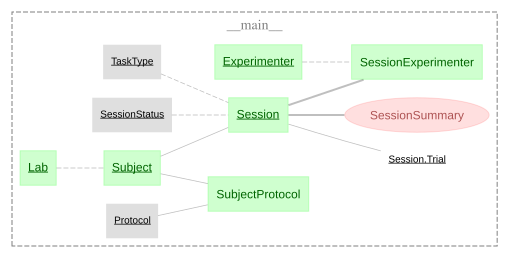

In [17]:
dj.Diagram(schema)

### Reading the Diagram

DataJoint diagrams show tables (nodes) and foreign keys (edges).

#### Line Styles
| Style        | Meaning                          |
|--------------|----------------------------------|
| Thick solid  | One-to-one (FK = entire PK)      |
| Thin solid   | One-to-many (FK in PK)           |
| Dashed       | Reference (FK in secondary attrs)|

#### Visual Indicators
- **Underlined name** — new primary key attributes  
- **Non-underlined** — PK fully inherited  
- **Colors**: Green (Manual), Gray (Lookup), Red (Computed), Blue (Imported)  
- **Orange dots** — renamed foreign keys  

#### Key Idea
- **Solid lines** → parent defines child identity  
- **Dashed lines** → child has independent identity  

*Note: Modifiers like `[nullable]` or `[unique]` are not shown in diagrams.*

## Insert Test Data and Populate

In [18]:
# Insert trials for the first session
import random
random.seed(42)

trials = []
for i in range(20):
    correct = random.random() > 0.3
    trials.append({
        'subject_id': 'M001',
        'session_idx': 1,
        'trial_idx': i + 1,
        'stimulus': random.choice(['left', 'right']),
        'response': random.choice(['go', 'nogo']),
        'correct': correct,
        'reaction_time': random.uniform(0.2, 0.8)
    })

Session.Trial.insert(trials, skip_duplicates=True)
print(f"Inserted {len(Session.Trial())} trials")

Inserted 20 trials


In [19]:
# Populate the computed summary
SessionSummary.populate(display_progress=True)
SessionSummary()

SessionSummary: 100%|██████████| 3/3 [00:00<00:00, 52.80it/s]


subject_id,session_idx,num_trials,num_correct,accuracy,mean_reaction_time
M001,1,20,14,0.7,0.5365
M001,2,0,0,0.0,0.0
M001,3,0,0,0.0,0.0


## Best Practices

1. **Primary Keys**
   - Use meaningful, natural identifiers when possible  
   - Keep keys minimal but unique  

2. **Table Tiers**
   - **Manual**: entered data  
   - **Lookup**: reference/config  
   - **Imported**: external data  
   - **Computed**: derived results  

3. **Normalization**
   - Avoid duplication  
   - Separate distinct entities  
   - Link with foreign keys  

4. **Data Types**
   - Prefer **DataJoint core types** (portable, consistent)  
   - Native DB types are allowed but discouraged  
   - Common types: `int32`, `float32`, `varchar(n)`, `bool`, `date`, `datetime`, `enum`, `json`, `uuid`  

5. **Documentation**
   - Add comments (`#`)  
   - Include units in attributes  

---

## Key Concepts Recap

| Concept            | Description                                      |
|--------------------|--------------------------------------------------|
| Primary Key        | Attributes above `---` (unique identifier)       |
| Secondary Attrs    | Attributes below `---`                           |
| Foreign Key (`->`) | Reference importing another table’s PK           |
| One-to-Many        | FK in PK                                         |
| One-to-One         | FK = entire PK                                   |
| Master-Part        | Insert/delete together                           |
| Nullable FK        | Optional reference (`[nullable]`)                |
| Unique FK          | Enforces one-to-one (`[unique]`)                 |
| Lookup Table       | Pre-populated reference data                     |

In [ ]:
# Cleanup
#schema.drop(prompt=False)